# 02 - Heat Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \alpha u_{xx}$, $\alpha = 0.01$

**IC:** $u(x,0) = \sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 32, 32, 32, 1]` | **Epochs:** 10000

**Note:** Heat equation is smooth - used as baseline to confirm AC-PINN
does not hurt performance on easy problems.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    HeatFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'heat'
LAYERS     = [2, 32, 32, 32, 1]
EPOCHS     = 10000
PDE_PARAMS = {'alpha': 0.01}
RESULTS    = '../results/heat/'
FIGURES    = '../figures/heat/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, alpha=0.01)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

HeatFDM solved in 0.3051s


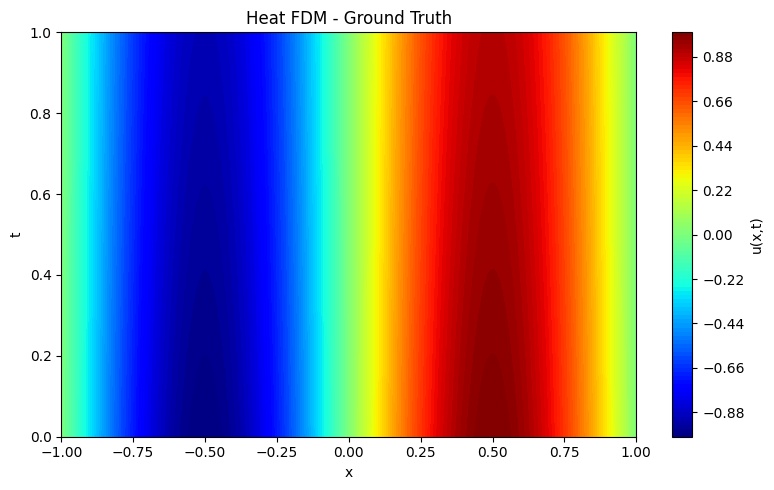

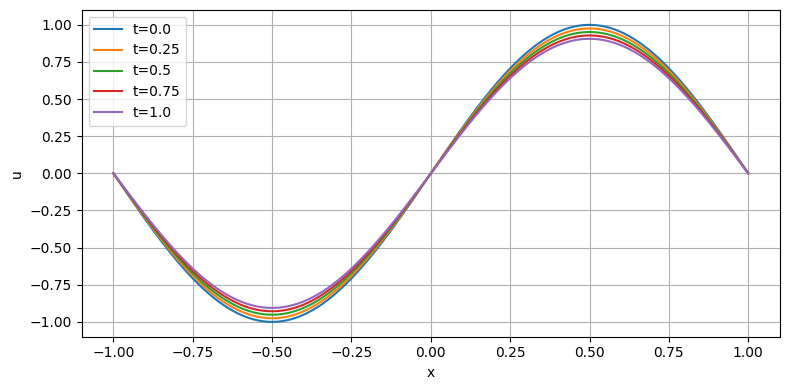

In [2]:
fdm = HeatFDM(nx=256, nt=1000, alpha=0.01)
fdm.solve()
fdm.plot_solution(title='Heat FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Heat | Vanilla Clean | Epoch     0/10000] Total: 0.795199 | IC: 0.595595 | BC: 0.048957 | PDE: 0.030129


[Heat | Vanilla Clean | Epoch  1000/10000] Total: 0.000213 | IC: 0.000057 | BC: 0.000014 | PDE: 0.000028


[Heat | Vanilla Clean | Epoch  2000/10000] Total: 0.000063 | IC: 0.000008 | BC: 0.000010 | PDE: 0.000009


[Heat | Vanilla Clean | Epoch  3000/10000] Total: 0.000042 | IC: 0.000005 | BC: 0.000010 | PDE: 0.000005


...

[Heat | Vanilla Clean | Epoch  6000/10000] Total: 0.000024 | IC: 0.000004 | BC: 0.000008 | PDE: 0.000003


[Heat | Vanilla Clean | Epoch  7000/10000] Total: 0.000020 | IC: 0.000003 | BC: 0.000007 | PDE: 0.000002


[Heat | Vanilla Clean | Epoch  8000/10000] Total: 0.000046 | IC: 0.000007 | BC: 0.000029 | PDE: 0.000002


[Heat | Vanilla Clean | Epoch  9000/10000] Total: 0.000039 | IC: 0.000007 | BC: 0.000015 | PDE: 0.000003



Training complete in 91.81s


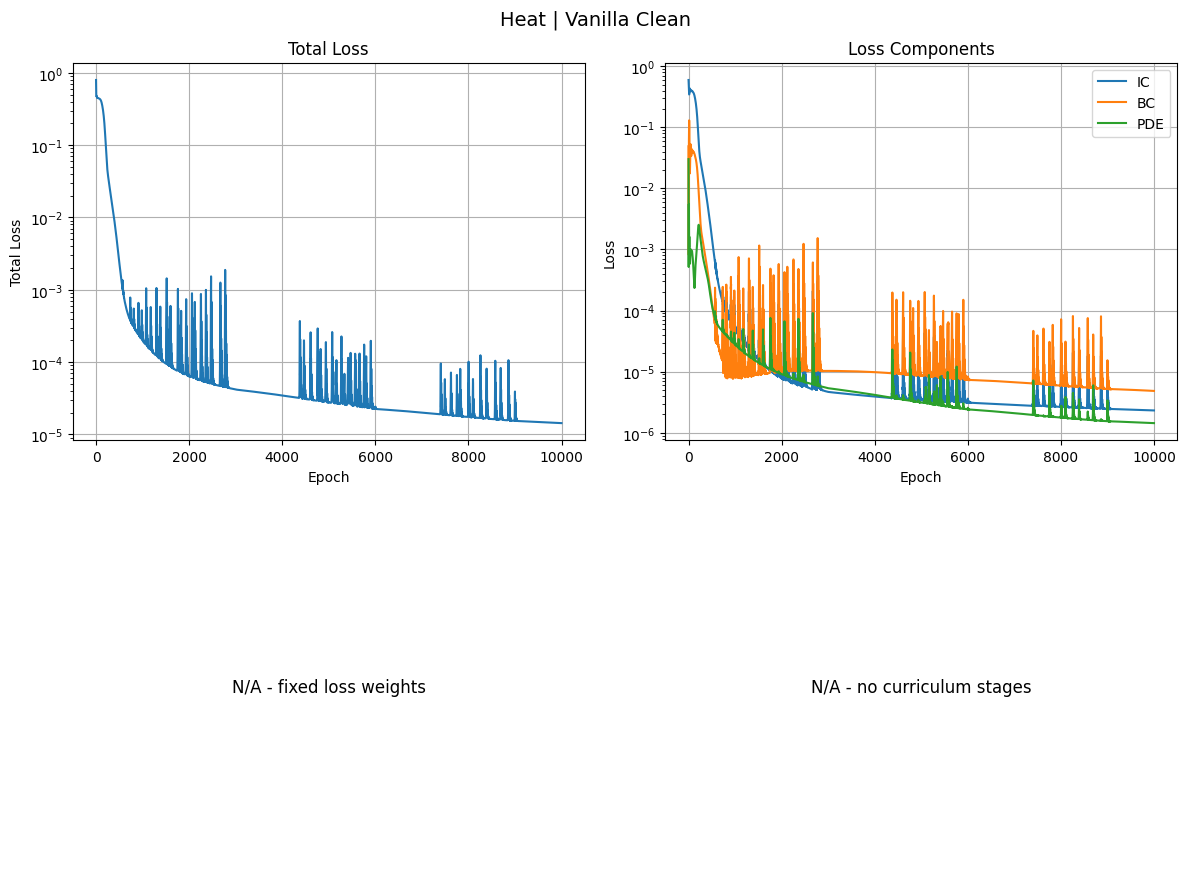

Saved: ../figures/heat/vanilla_clean_training.png
Saved: ../figures/heat/vanilla_clean_training.csv


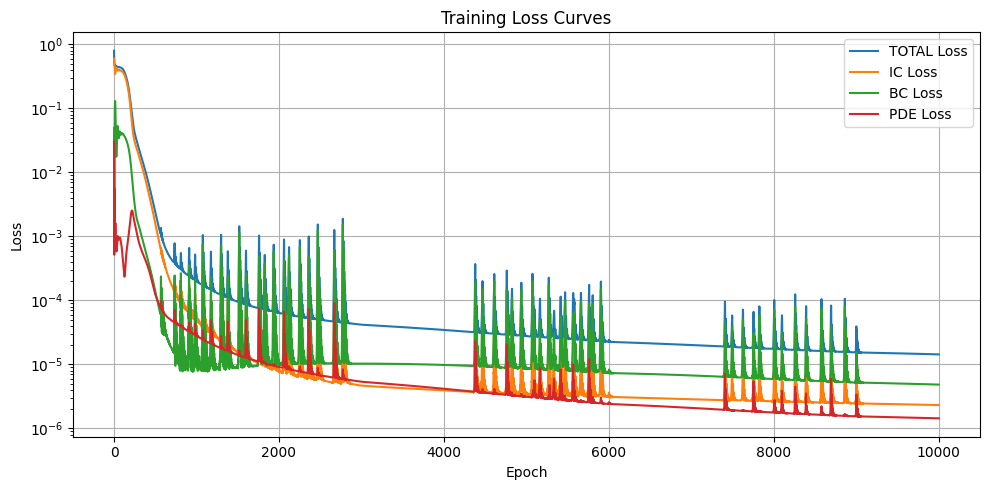

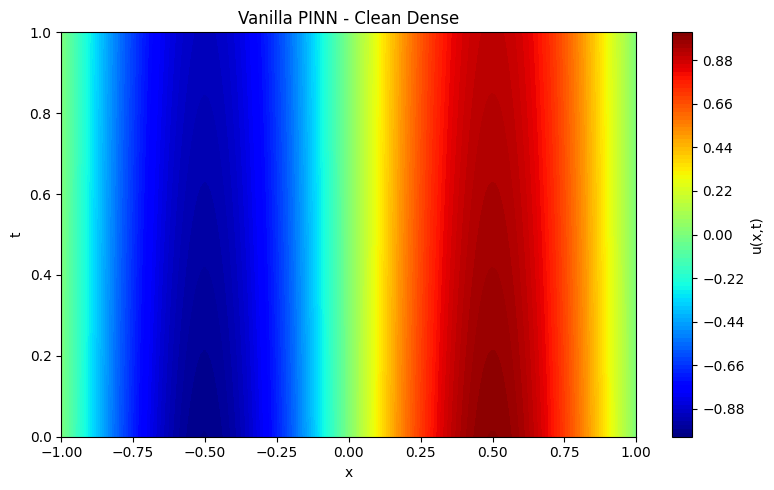

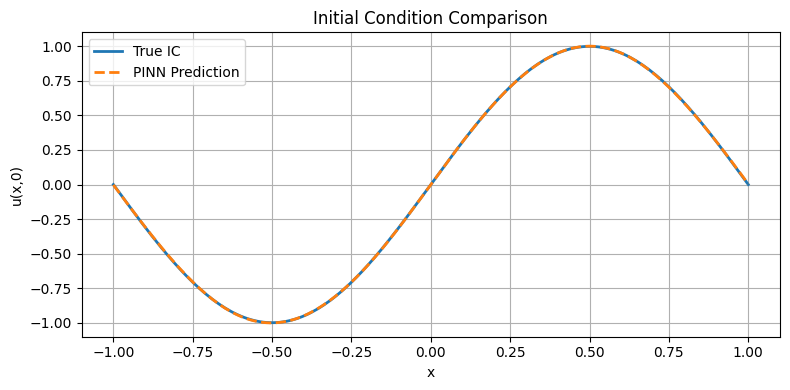

Saved: ../results/heat/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Heat | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

[Heat | Vanilla Noisy | Epoch     0/10000] Total: 0.548939 | IC: 0.516886 | BC: 0.026976 | PDE: 0.001015


[Heat | Vanilla Noisy | Epoch  1000/10000] Total: 0.029323 | IC: 0.005006 | BC: 0.023759 | PDE: 0.000112


[Heat | Vanilla Noisy | Epoch  2000/10000] Total: 0.028147 | IC: 0.004645 | BC: 0.023261 | PDE: 0.000048


[Heat | Vanilla Noisy | Epoch  3000/10000] Total: 0.027867 | IC: 0.004593 | BC: 0.023146 | PDE: 0.000026


[Heat | Vanilla Noisy | Epoch  4000/10000] Total: 0.027813 | IC: 0.004588 | BC: 0.023106 | PDE: 0.000024


...

[Heat | Vanilla Noisy | Epoch  6000/10000] Total: 0.027749 | IC: 0.004590 | BC: 0.023037 | PDE: 0.000024


[Heat | Vanilla Noisy | Epoch  7000/10000] Total: 0.027735 | IC: 0.004593 | BC: 0.023020 | PDE: 0.000024


[Heat | Vanilla Noisy | Epoch  8000/10000] Total: 0.027720 | IC: 0.004597 | BC: 0.022998 | PDE: 0.000025


[Heat | Vanilla Noisy | Epoch  9000/10000] Total: 0.027706 | IC: 0.004598 | BC: 0.022982 | PDE: 0.000025



Training complete in 89.01s


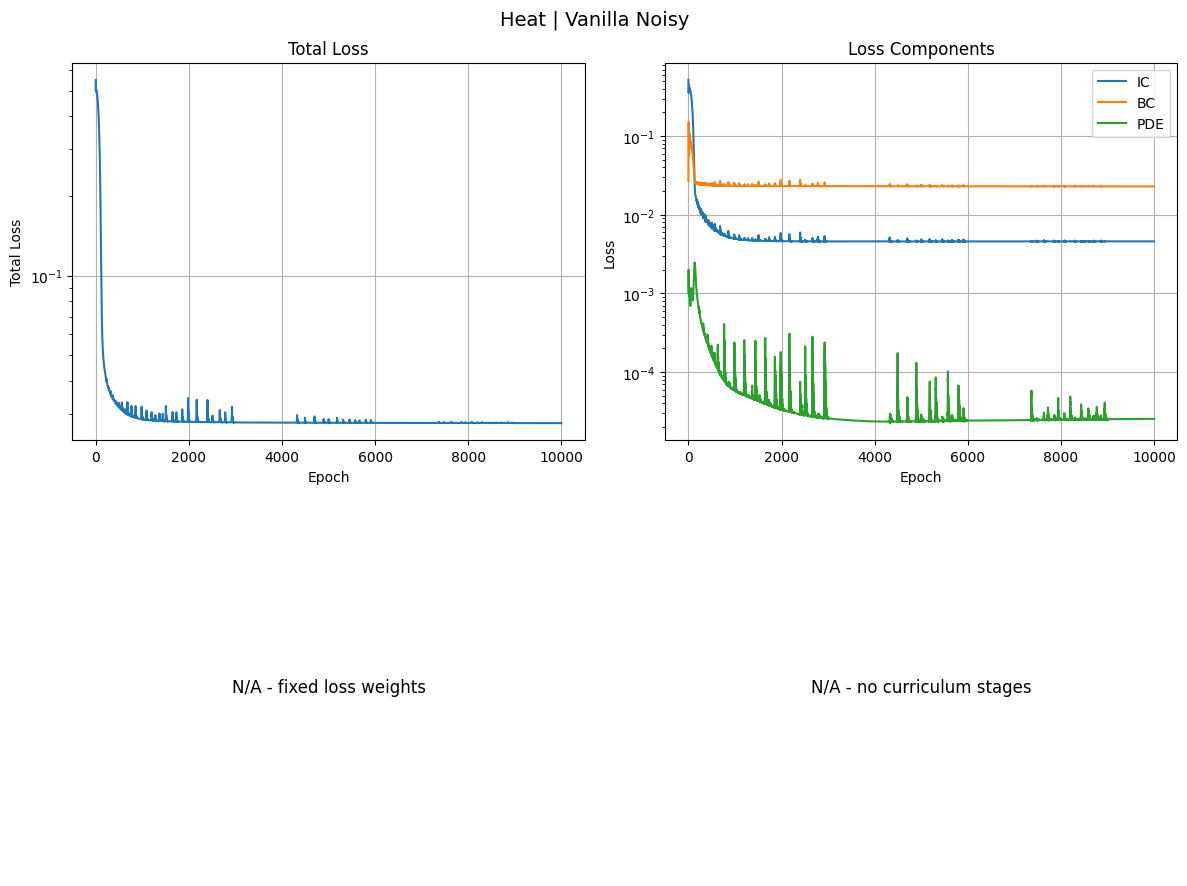

Saved: ../figures/heat/vanilla_noisy_training.png
Saved: ../figures/heat/vanilla_noisy_training.csv


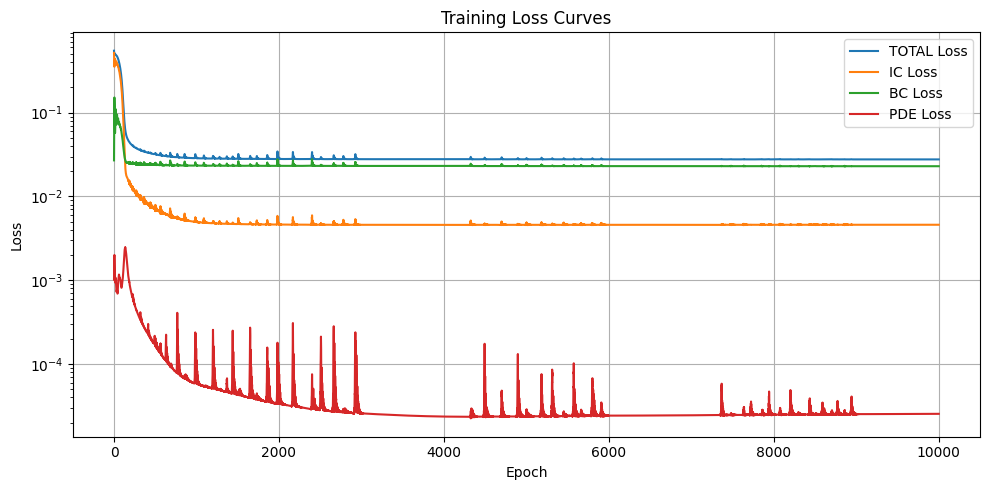

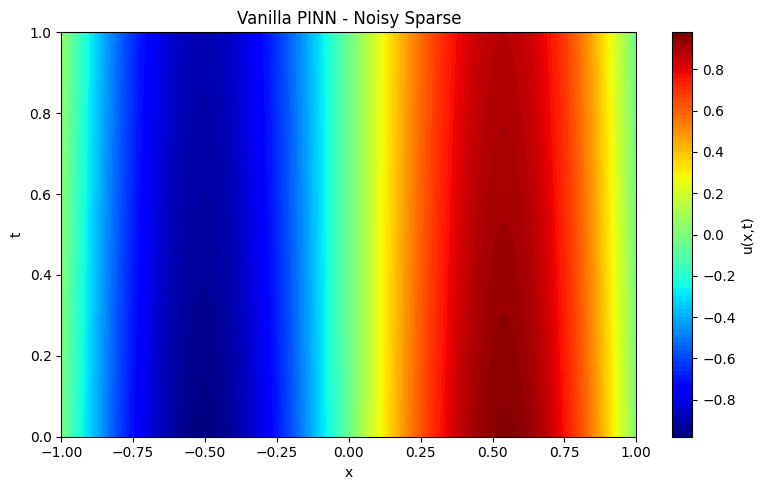

Saved: ../results/heat/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Heat | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Heat | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.616594 | IC: 0.588987 | BC: 0.019683 | PDE: 0.001585 | lam=(1.00,1.00,5.00)


[Heat | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.000366 | IC: 0.000030 | BC: 0.000067 | PDE: 0.000018 | lam=(2.50,1.68,10.00)


[Heat | AC-PINN Clean | Epoch  2000/10000] Stage 3/4 | Total: 0.000058 | IC: 0.000012 | BC: 0.000022 | PDE: 0.000021 | lam=(0.65,1.19,1.16)


[Heat | AC-PINN Clean | Epoch  3000/10000] Stage 3/4 | Total: 0.000039 | IC: 0.000008 | BC: 0.000013 | PDE: 0.000015 | lam=(0.64,1.10,1.26)


[Heat | AC-PINN Clean | Epoch  4000/10000] Stage 3/4 | Total: 0.000030 | IC: 0.000006 | BC: 0.000009 | PDE: 0.000013 | lam=(0.64,1.01,1.35)


...

[Heat | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000017 | IC: 0.000003 | BC: 0.000004 | PDE: 0.000007 | lam=(0.66,0.85,1.49)


[Heat | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000014 | IC: 0.000003 | BC: 0.000003 | PDE: 0.000006 | lam=(0.65,0.81,1.54)


[Heat | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.000041 | IC: 0.000003 | BC: 0.000005 | PDE: 0.000018 | lam=(0.32,0.59,2.09)


[Heat | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.000017 | IC: 0.000002 | BC: 0.000003 | PDE: 0.000007 | lam=(0.47,0.77,1.75)



AC-PINN training complete in 105.19s


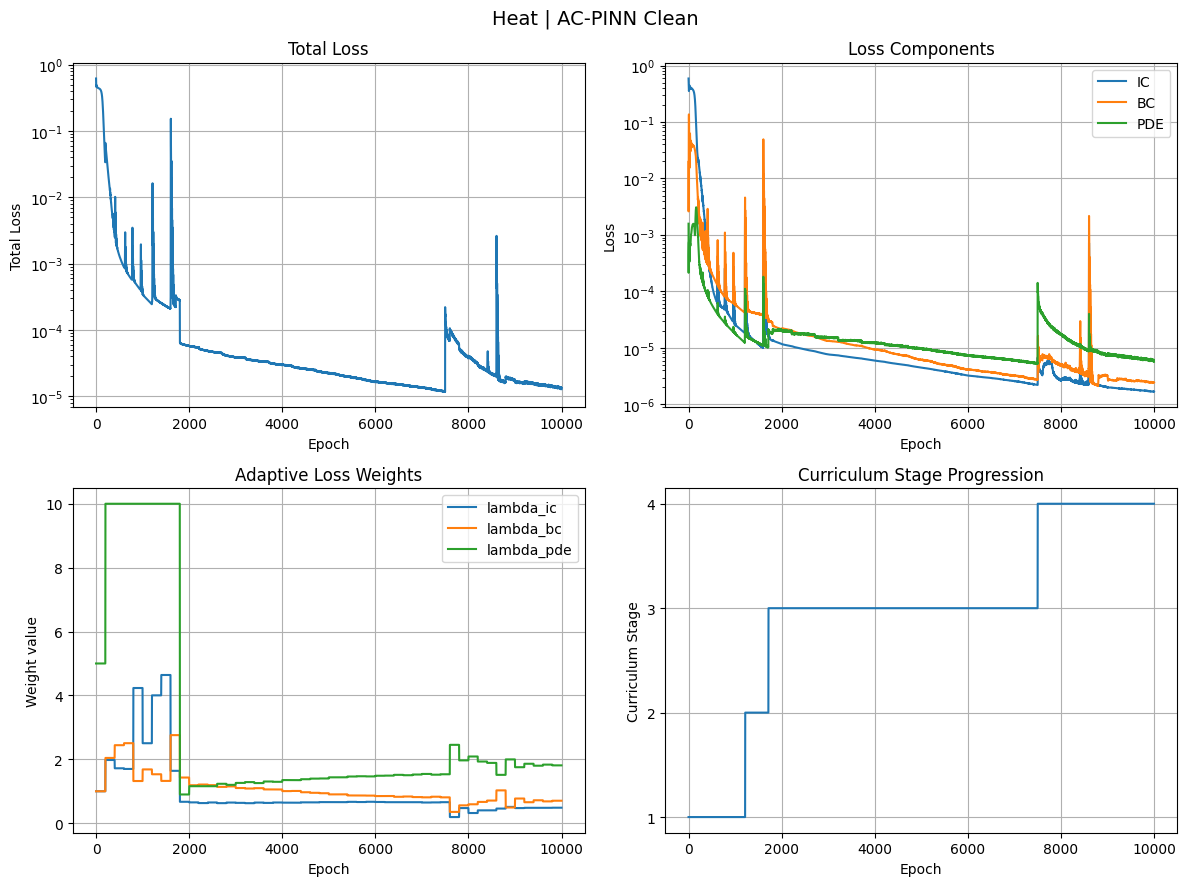

Saved: ../figures/heat/acpinn_clean_training.png
Saved: ../figures/heat/acpinn_clean_training.csv


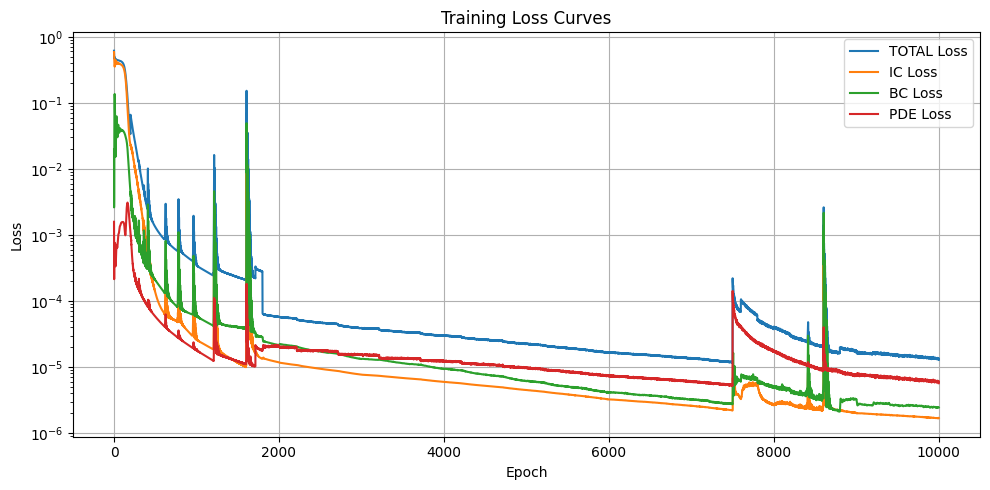

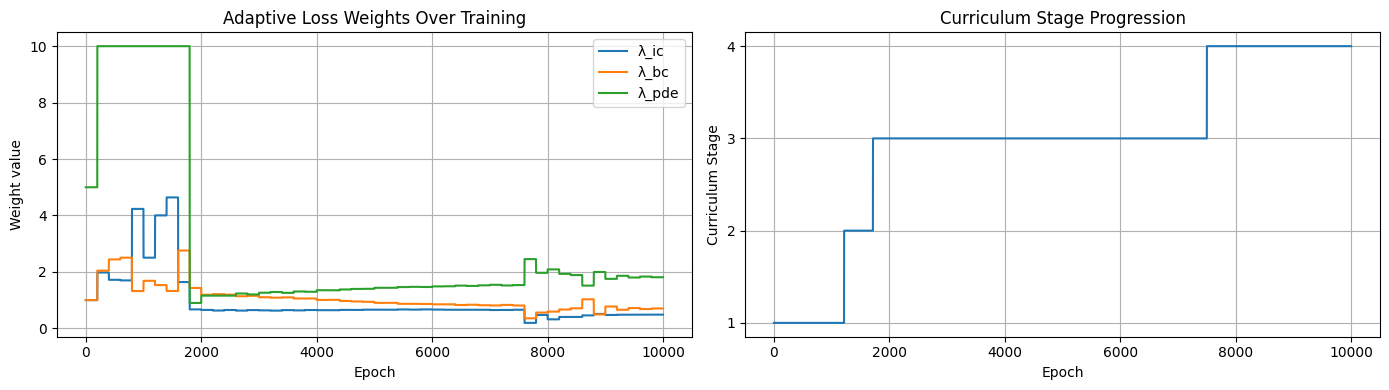

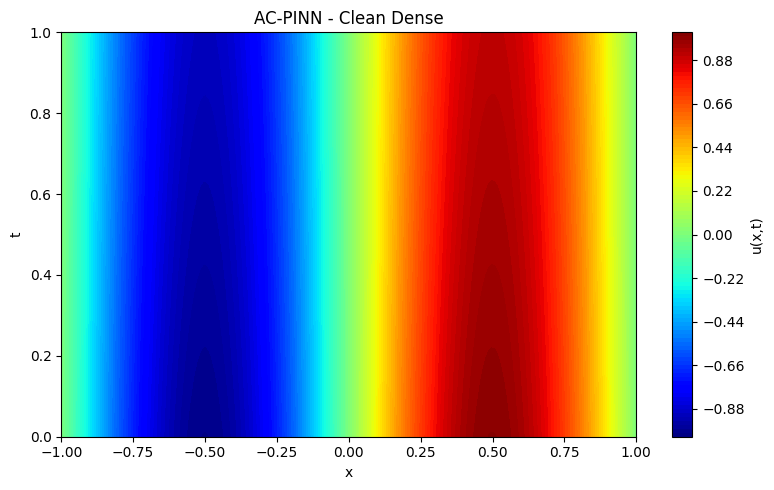

Saved: ../results/heat/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Heat | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

[Heat | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.595581 | IC: 0.296812 | BC: 0.293036 | PDE: 0.001146 | lam=(1.00,1.00,5.00)


[Heat | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.066321 | IC: 0.004713 | BC: 0.022651 | PDE: 0.000020 | lam=(8.31,1.19,10.00)


[Heat | AC-PINN Noisy | Epoch  2000/10000] Stage 2/4 | Total: 0.064584 | IC: 0.004497 | BC: 0.023050 | PDE: 0.000010 | lam=(8.49,1.14,10.00)


[Heat | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.049943 | IC: 0.004835 | BC: 0.023525 | PDE: 0.000012 | lam=(3.00,1.50,10.00)


[Heat | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.047934 | IC: 0.004518 | BC: 0.022671 | PDE: 0.000009 | lam=(3.26,1.46,10.00)


...

[Heat | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.044733 | IC: 0.005476 | BC: 0.018551 | PDE: 0.001153 | lam=(0.65,2.21,0.14)


[Heat | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.040315 | IC: 0.005997 | BC: 0.017211 | PDE: 0.001735 | lam=(0.72,2.07,0.21)


[Heat | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.043251 | IC: 0.005385 | BC: 0.018357 | PDE: 0.012525 | lam=(0.45,1.52,1.04)


[Heat | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.047733 | IC: 0.005081 | BC: 0.020294 | PDE: 0.002537 | lam=(0.55,2.18,0.27)



AC-PINN training complete in 102.45s


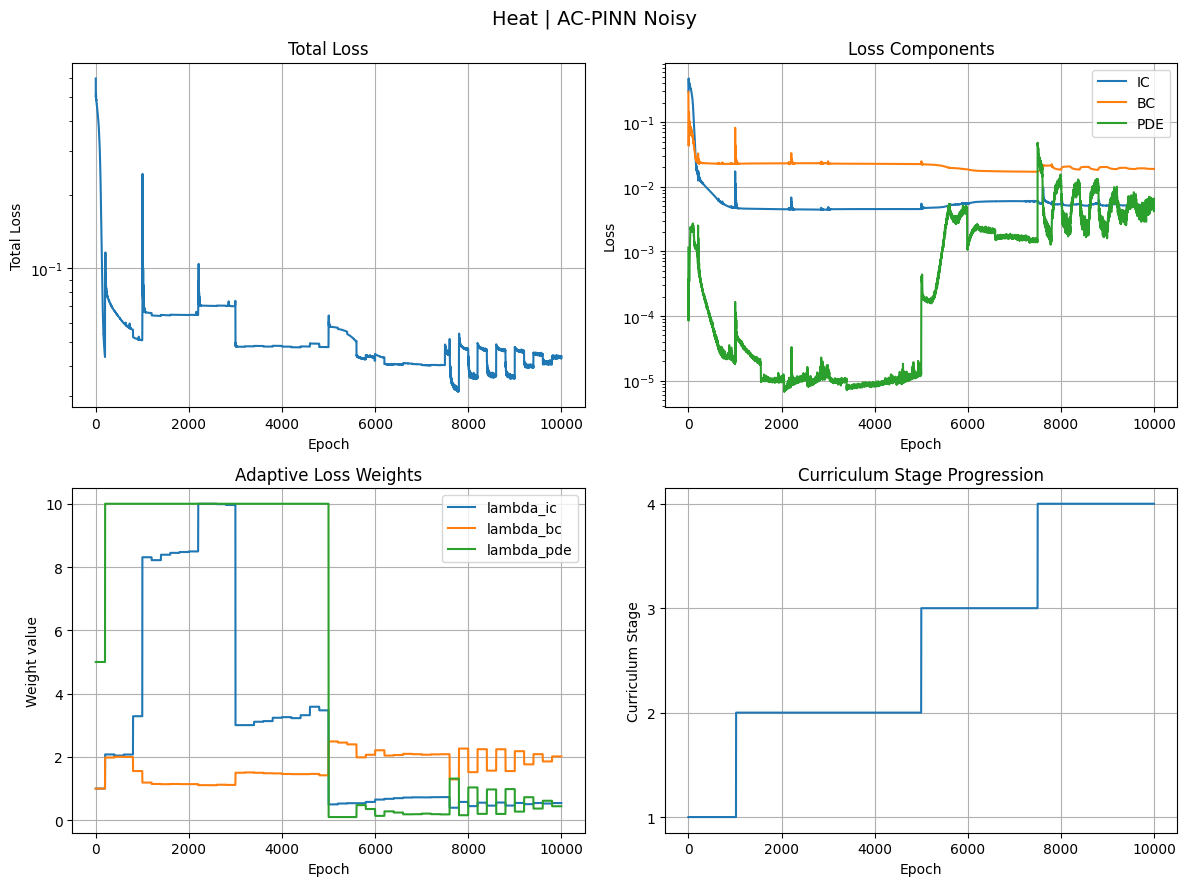

Saved: ../figures/heat/acpinn_noisy_training.png
Saved: ../figures/heat/acpinn_noisy_training.csv


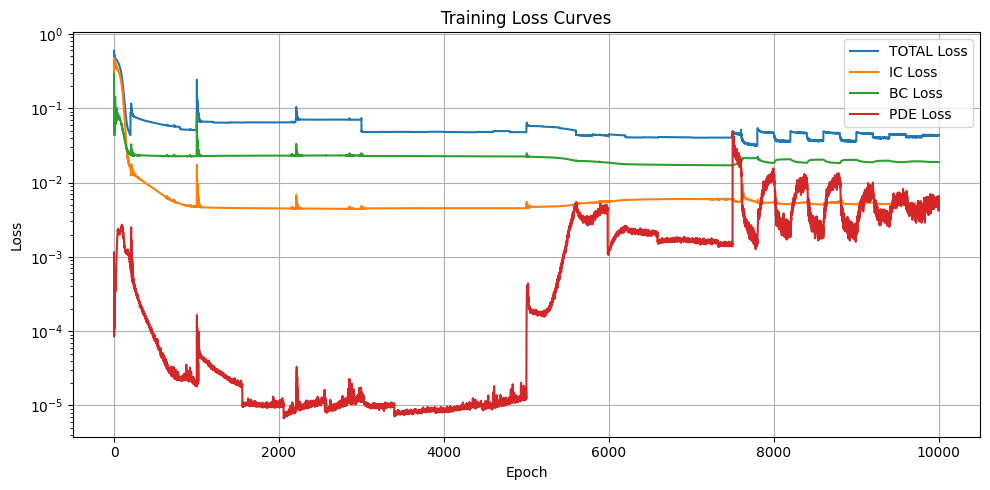

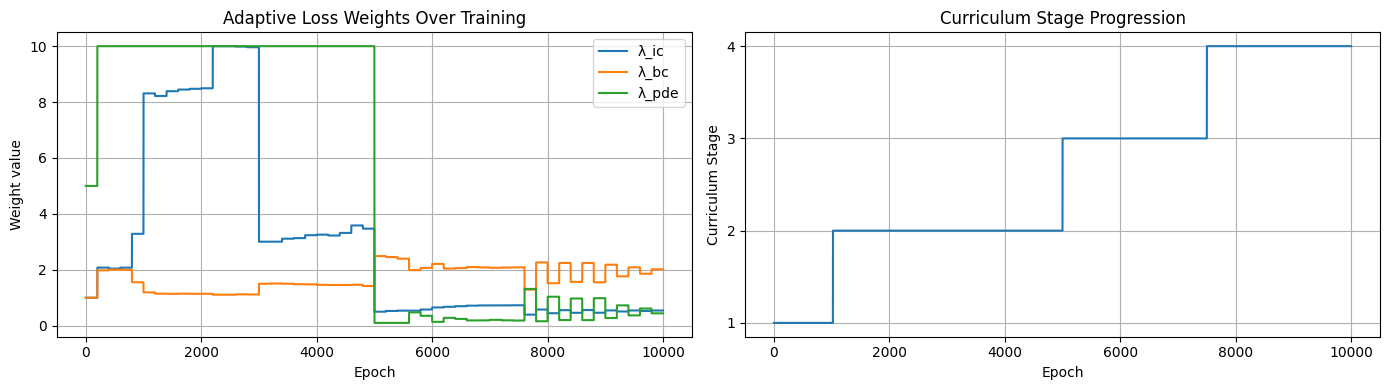

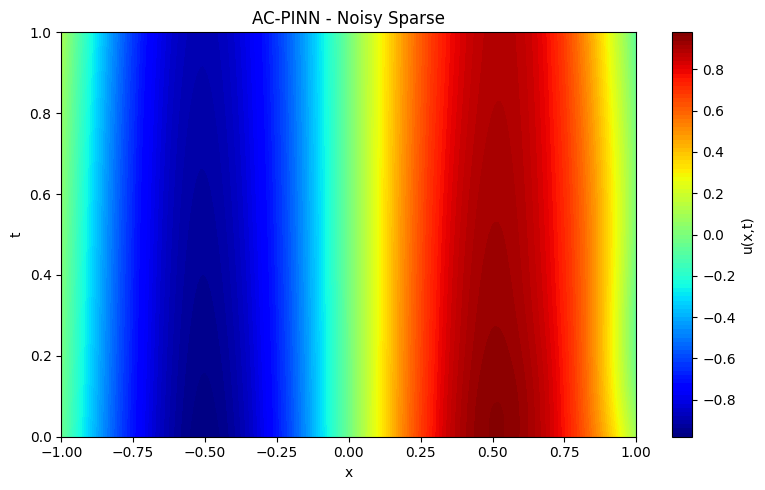

Saved: ../results/heat/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Heat | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.001390   0.003833   0.000734   0.000934
  Vanilla (noisy)             0.058184   0.083174   0.031499   0.039112
  AC-PINN (clean)             0.001393   0.003641   0.000792   0.000936
  AC-PINN (noisy)             0.043879   0.102840   0.024578   0.029496


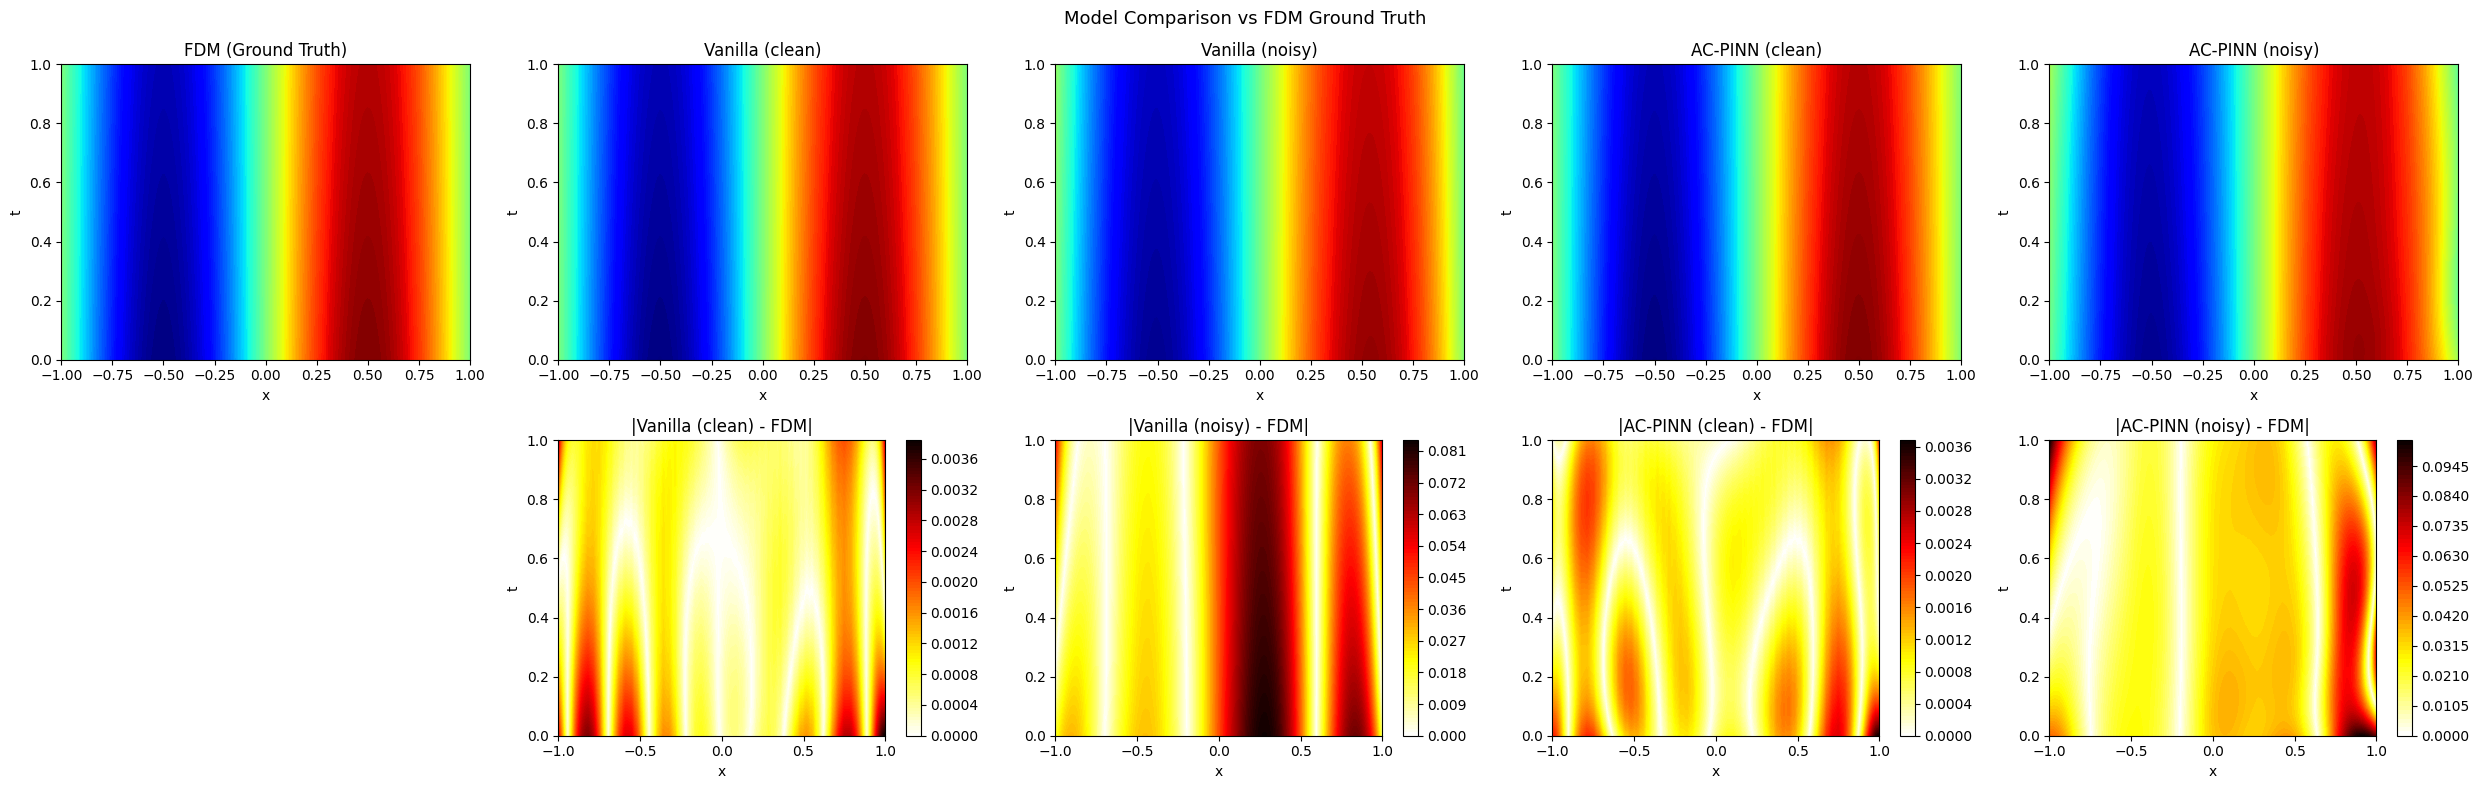

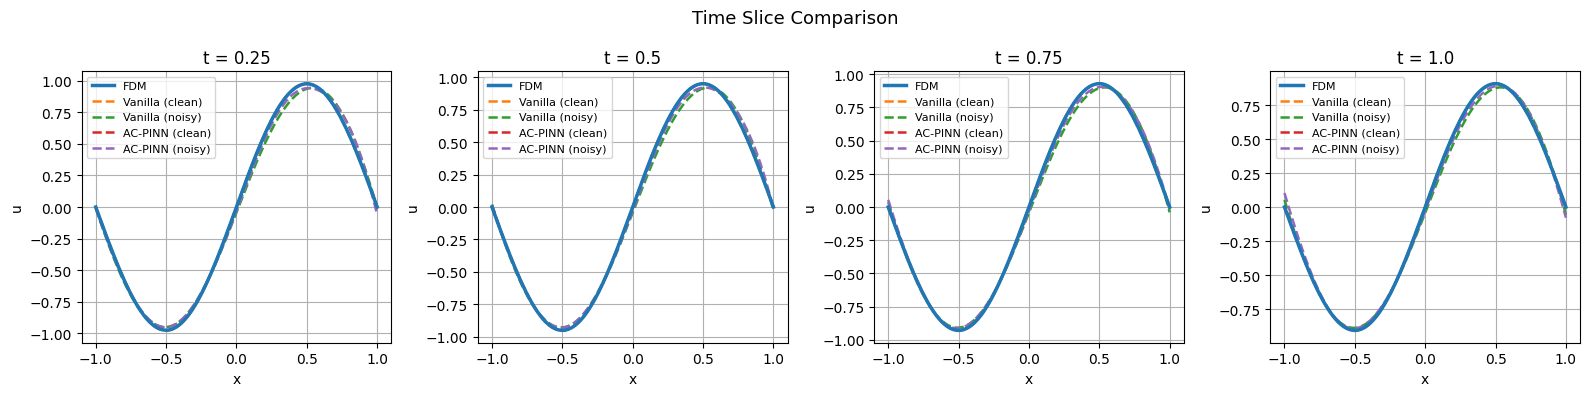

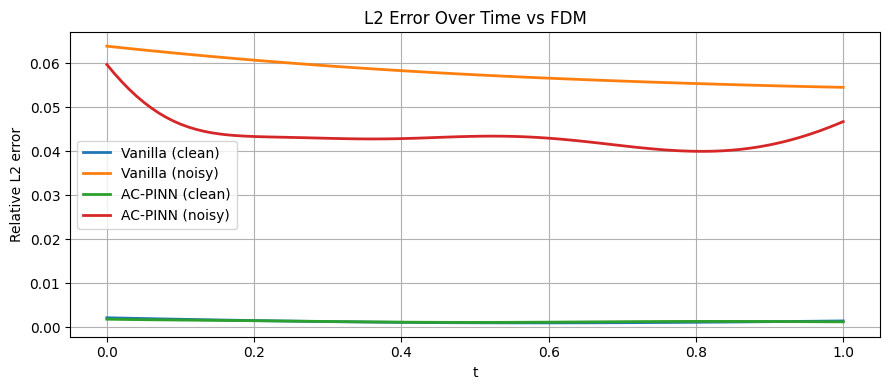

Saved: ../results/heat/benchmark_metrics.npy
Heat experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Heat experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.495556 | IC: 0.487027 | BC: 0.005437 | PDE: 0.000618


[Epoch  2500/5000] Total: 0.006774 | IC: 0.002649 | BC: 0.004018 | PDE: 0.000022



Training complete in 45.06s
[Epoch     0/5000] Stage 1/4 | Total: 1.595028 | IC: 0.679526 | BC: 0.213226 | PDE: 0.140455 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 4/4 | Total: 0.009727 | IC: 0.002640 | BC: 0.003909 | PDE: 0.000303 | lam=(1.15,1.70,0.15)



AC-PINN training complete in 52.09s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.025525   0.038879   0.013974   0.017159
  AC-PINN ε=0.05              0.024624   0.047424   0.013505   0.016553

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.753363 | IC: 0.626175 | BC: 0.106059 | PDE: 0.004226


...


AC-PINN training complete in 52.21s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.045078   0.054965   0.026881   0.030303
  AC-PINN ε=0.1               0.053605   0.067619   0.031498   0.036034

--- ε=0.2 ---
[Epoch     0/5000] Total: 1.230133 | IC: 0.643242 | BC: 0.193724 | PDE: 0.078633


[Epoch  2500/5000] Total: 0.121351 | IC: 0.046836 | BC: 0.072402 | PDE: 0.000423



Training complete in 45.10s
[Epoch     0/5000] Stage 1/4 | Total: 1.041015 | IC: 0.431304 | BC: 0.186156 | PDE: 0.084711 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.340249 | IC: 0.038648 | BC: 0.067315 | PDE: 0.001847 | lam=(6.15,1.25,10.00)



AC-PINN training complete in 52.09s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.086359   0.202679   0.045230   0.058052
  AC-PINN ε=0.2               0.102640   0.232052   0.053106   0.068997
Saved: ../results/heat/noise_study_metrics.npy
